# **Importing Pandas and transforming DataFrames for Visualization/Analysis**

In [29]:
import pandas as pd
!pip install dataframe_image

In [30]:
# Importing the Short Table generated through MySQL transformation pipeline
df_short= pd.read_csv("/content/drive/MyDrive/FedReserveProject/macroeconomic_data_short.csv")

# Creating a DateTime index column for time-series visualization convenience
df_short['date'] = pd.PeriodIndex(
    year=df_short['YEAR'],
    quarter=df_short['QUARTER'],
    freq='Q').to_timestamp()
df_short.head()

/tmp/ipykernel_816/4019760191.py:5: FutureWarning: Constructing PeriodIndex from fields is deprecated. Use PeriodIndex.from_fields instead.
  df_short['date'] = pd.PeriodIndex(


,YEAR,QUARTER,fed_funds_rate,cpi,pce,unemployment_rate,gdp,date
0,1947,1,NaN,21.810000,NaN,NaN,NaN,1947-01-01
1,1947,2,NaN,22.010000,NaN,NaN,245.968,1947-04-01
2,1947,3,NaN,22.490000,NaN,NaN,249.585,1947-07-01
3,1947,4,NaN,23.126667,NaN,NaN,259.745,1947-10-01
4,1948,1,NaN,23.616667,NaN,NaN,265.742,1948-01-01


# **Exploratory Data Analysis**

In [31]:
# Shape of the imported short table generated through the SQL transformation pipeline
df_short.shape

(318, 8)

In [32]:
# Checking for Null Values in the dataFrame, null observations are expected due to staggered start dates for each indicator
# Null values will be dropped after initial visualizations of each indicator are constructed
df_short.isnull().sum()

,0
YEAR,0
QUARTER,0
fed_funds_rate,30
cpi,0
pce,48
unemployment_rate,6
gdp,2
date,0


In [33]:
df_short.drop(columns= ['date','QUARTER','YEAR']).describe()

,fed_funds_rate,cpi,pce,unemployment_rate,gdp
count,288.000000,318.000000,270.000000,312.000000,316.000000
mean,4.597506,125.359703,6158.846235,5.664423,7850.515851
std,3.513584,90.702391,5739.788008,1.697298,8266.631895
min,0.060000,21.810000,311.150000,2.600000,245.968000
25%,1.940000,32.904167,1084.675000,4.300000,841.453000
50%,4.313333,110.083333,4267.100000,5.500000,4632.648000
75%,6.210000,202.066667,10077.625000,6.725000,13782.615000
max,17.780000,332.407000,21979.400000,13.000000,31819.464000


The summary statistics provide an overview of the scale and variability of the Federal Funds rate and each macroeconomic indicator used throughout the analysis. Each variable exhibits substantially different ranges and units of measurement, reflecting the distinct economic concepts they represent. These differences highlight the need to interpret each variable within its appropriate economic context when making comparisons. A more detailed examination of the variables follows through time-series visualizations and the subsequent lagged correlation analysis.

In [34]:
# Importing Matplotlib and Seaborn libraries for Time-Series vizualization of trends and Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

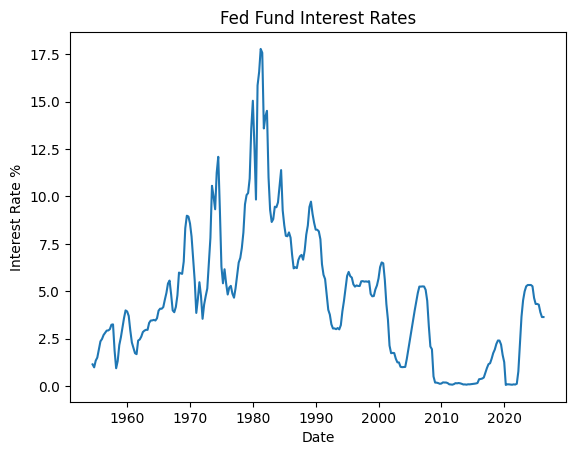

In [35]:
# Displaying FedFund Interest Rates Over Time
plt.plot(df_short['date'],df_short['fed_funds_rate'])
plt.title('Fed Fund Interest Rates')
plt.xlabel('Date')
plt.ylabel('Interest Rate %')
plt.savefig('fedfund_rate.png')
plt.show()

Visualizing the Federal Funds Rate Observations over time it's evident that changes occur cyclically, delineating periods of expansionary and contractionary monetary policy. The Tightening cycle of the 1980s represents a notable peak in the dataset with interest rates reaching historically elevated levels as the Federal Reserve implemented restrictive monetary policy to address high inflation. Outside of this period, the Federal Funds Rate generally remained below 10% throughout the observed timeframe, with subsequent cycles reflecting changes in the broader economic environment and inflation conditions.

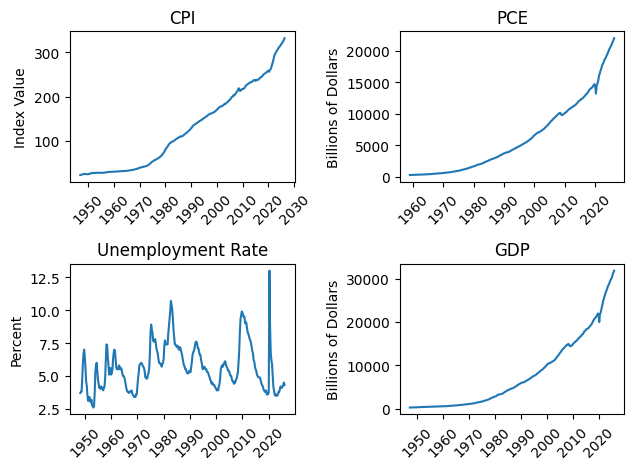

In [36]:
# Displaying the Indicator Metrics over time
fig, axs = plt.subplots(2, 2)

# CPI Over Time
axs[0, 0].plot(df_short['date'],df_short['cpi'])
axs[0, 0].set_title('CPI')
axs[0, 0].set_ylabel('Index Value')

# PCE Over Time
axs[0, 1].plot(df_short['date'],df_short['pce'])
axs[0, 1].set_title('PCE')
axs[0, 1].set_ylabel('Billions of Dollars')

# Unemployment Over Time
axs[1, 0].plot(df_short['date'],df_short['unemployment_rate'])
axs[1, 0].set_title('Unemployment Rate')
axs[1, 0].set_ylabel('Percent')

# GDP Over Time
axs[1, 1].plot(df_short['date'],df_short['gdp'])
axs[1, 1].set_title('GDP')
axs[1, 1].set_ylabel('Billions of Dollars')

for ax in axs.flat:
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('macroeconomic_indicators.png')
plt.show()

Visualizing each macroeconomic indicator over time highlights the distinct long-term trends and cyclical patterns present across the dataset. GDP demonstrates a strong upward trend over time, reflecting overall economic expansion, while CPI and PCE exhibit gradual increases consistent with long-term inflationary trends. Short-term declines or disruptions are visible during recessionary periods, where economic activity and inflation dynamics can shift. In contrast, unemployment figures are more volatile, as they are expressed as a percentage rate and respond quicker to changes in labor market conditions. These differences in scale and economic behavior emphasize the importance of carefully considering each indicator's context when evaluating their relationships with Federal Funds Rate movements.

# **Demonstrating Analysis of Lagged Data**

For this project the Federal Funds Interest Rate acts as a potential leading indicator. Where GDP CPI, PCE, & Unemployment represent the responding economic indicators to Interest Rate changes. Monetary policy typically influences the economy with a delay, and to investigate this, lagged Federal Funds Rate variables are created across multiple quarterly horizons to gauge lagged impact on the greater economic landscape.

In [37]:
# Dropping null values for accurate correlation analysis of the overlapping period of observations
df_short = df_short.dropna(
    subset=['fed_funds_rate', 'pce', 'cpi', 'unemployment_rate', 'gdp'])

# Count of null values
df_short.isnull().sum()

,0
YEAR,0
QUARTER,0
fed_funds_rate,0
cpi,0
pce,0
unemployment_rate,0
gdp,0
date,0


In [38]:
# Quarter Over Quarter Change in FedFund Interest Rates
df_short['fed_change'] = (
    df_short['fed_funds_rate'].diff())

# Standardizing the CPI, PCE, and GDP data into a quarter over quarter difference percentages to reduce long-term trend impact
df_short['cpi_qoq'] = (
    df_short['cpi'].pct_change(fill_method=None))

df_short['pce_qoq'] = (
    df_short['pce'].pct_change(fill_method=None))

df_short['gdp_qoq'] = (
    df_short['gdp'].pct_change(fill_method=None))

# Quarter Over Quarter Change in Unemployment Rate which already formatted as a percentage
df_short['unemployment_qoq'] = (
    df_short['unemployment_rate'].diff())

# Updated dataFrame
df_short.loc[df_short['YEAR'] == 2022]

,YEAR,QUARTER,fed_funds_rate,cpi,pce,unemployment_rate,gdp,date,fed_change,cpi_qoq,pce_qoq,gdp_qoq,unemployment_qoq
300,2022,1,0.120000,284.905667,17149.000000,3.9,25250.347,2022-01-01,0.040000,0.022005,0.019863,0.017601,-0.3
301,2022,2,0.770000,291.605333,17606.566667,3.6,25861.292,2022-04-01,0.650000,0.023515,0.026682,0.024196,-0.3
302,2022,3,2.190000,295.453000,17893.133333,3.5,26336.304,2022-07-01,1.420000,0.013195,0.016276,0.018368,-0.1
303,2022,4,3.653333,298.541667,18111.366667,3.6,26770.514,2022-10-01,1.463333,0.010454,0.012196,0.016487,0.1


In [39]:
# Incorporating 1 Quarter Lagged Fed Funds Data into the short dataFrame
df_short['fed_lag_quarter'] = df_short['fed_change'].shift(1)

# Incorporating 1 Year Lagged Fed Funds Data into the short dataFrame
df_short['fed_lag_year'] = df_short['fed_change'].shift(4)

# Displays the updated short dataFrame
df_short.iloc[52:60]

,YEAR,QUARTER,fed_funds_rate,cpi,pce,unemployment_rate,gdp,date,fed_change,cpi_qoq,pce_qoq,gdp_qoq,unemployment_qoq,fed_lag_quarter,fed_lag_year
100,1972,1,3.546667,41.333333,738.966667,5.8,1230.609,1972-01-01,-1.203333,0.008130,0.023925,0.033867,-0.1,-0.726667,-1.710000
101,1972,2,4.300000,41.600000,757.366667,5.7,1266.369,1972-04-01,0.753333,0.006452,0.024900,0.029059,-0.1,-1.203333,0.710000
102,1972,3,4.743333,41.933333,775.766667,5.6,1290.566,1972-07-01,0.443333,0.008013,0.024295,0.019107,-0.1,0.753333,0.910000
103,1972,4,5.146667,42.366667,800.500000,5.4,1328.904,1972-10-01,0.403333,0.010334,0.031882,0.029706,-0.2,0.443333,-0.726667
104,1973,1,6.536667,43.033333,825.033333,4.9,1377.490,1973-01-01,1.390000,0.015736,0.030648,0.036561,-0.5,0.403333,-1.203333
105,1973,2,7.816667,43.933333,840.533333,4.9,1413.887,1973-04-01,1.280000,0.020914,0.018787,0.026423,0.0,1.390000,0.753333
106,1973,3,10.560000,44.800000,858.866667,4.8,1433.838,1973-07-01,2.743333,0.019727,0.021812,0.014111,-0.1,1.280000,0.443333
107,1973,4,9.996667,45.933333,873.900000,4.8,1476.289,1973-10-01,-0.563333,0.025298,0.017504,0.029607,0.0,2.743333,0.403333


After implementing the Lagged Data & corr function from Pandas library, the returned correlation matrix shows the r correlation relationships of all columns in the DataFrame. This process is repeated for each metric individually to determine the number of quarters with the strongest relationship to each indicator for the affects from interest rate changes to present themselves.

<Axes: >

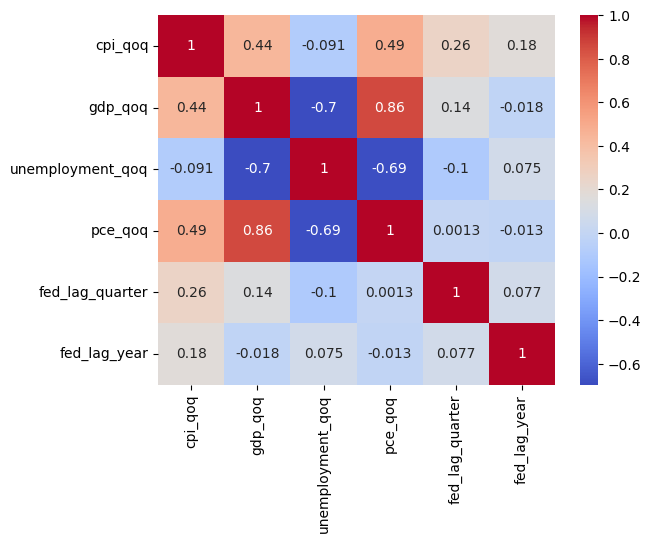

In [40]:
# Exploring the correlation (r) between each metric
corr_example = df_short[[
     'cpi_qoq',
     'gdp_qoq',
     'unemployment_qoq',
     'pce_qoq',
     'fed_lag_quarter',
     'fed_lag_year']].corr()

sns.heatmap(corr_example, annot=True, cmap='coolwarm',)


In [41]:
# Dropping the unneeded lag columns from DataFrame
df_short=df_short.drop(columns=['fed_lag_quarter','fed_lag_year'])

# **Lagged Impact Analysis of FedFund Interest Rates on Inflation**

The objective of this analysis is to investigate the timing of the relationship between changes in the Federal Funds Rate and inflation indicators, specifically CPI and PCE. The central question is: When the Federal Funds Rate changes, how many quarters later do we observe the strongest relationship with inflation measures?

To approach answering this, a series of lagged Federal Funds Rate variables are created, with each lag representing a different number of quarters between monetary policy actions and observed economic effects. The correlation between each lagged rate series and the inflation indicators is then calculated. By comparing correlations across multiple lag lengths, the analysis identifies the time horizon at which the relationship between monetary policy and inflation appears strongest.

The approach is similar to a parameter search, where multiple lag  intervals are evaluated and compared to determine which lag interval provides the strongest statistical correlation.

In [42]:
# Repeateable parameter search algorithm function to be used on all indicator types
def lag_parameter_search(df, indicator, max_lag=8):

    results = []

    # Loop to obtain correlation scores for each lag interval
    for lag in range(1, max_lag + 1):
        corr = df["fed_change"].shift(lag).corr(df[indicator])
        results.append([lag, corr])

    # DataFrame Containing Correlations at each lag interval
    results = pd.DataFrame(results, columns=["quarters_lag", "corr"])

    # Highest correlation value present
    best = results.loc[results["corr"].abs().idxmax()]

    return results, best

In [43]:
# Initializing a DataFrame to store the most correlated quarter for each indicator
max_indicators=pd.DataFrame(columns=['Quarter', 'Peak_corr'], index=['CPI','PCE','GDP','Unemployment'])

The Search Algorithm is used to discover the strongest relationship between the Fed Funds Rate and the CPI inflation metric in terms of lagged quarters ranging up to 2 years previous. The resulting Plot showcases the correlation of each lagged time horizon's relationship with the Consumer Price Index.

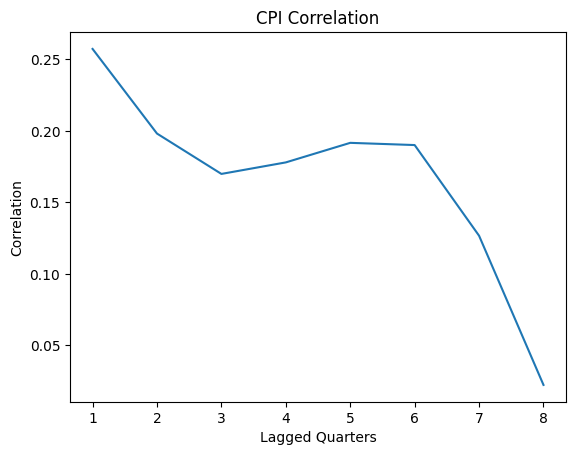

In [44]:
# Calculate the correlation between lagged Federal Funds Rate and CPI
cpi_results, cpi_best = lag_parameter_search(df_short, "cpi_qoq")
max_indicators.loc['CPI'] = cpi_best['quarters_lag'], cpi_best['corr']

# Visualize correlation by lag
plt.plot(cpi_results['quarters_lag'],cpi_results['corr'])
plt.title('CPI Correlation')
plt.xlabel('Lagged Quarters')
plt.ylabel('Correlation')
plt.savefig('cpi_correlation.png')
plt.show()

Interpreting this Plot, it's visible that the correlation between the FedFund Interest Rate changes and Consumer Price Index growth is strongest at the 1 quarter mark within a 2 year time frame. The relationship consistently weakens as the lag interval increases, suggesting that changes in the Federal Funds Rate are more closely associated with CPI movements in the near term than over longer horizons. While this analysis identifies the timing of the strongest relationship, correlation alone does not establish a causal effect. The correlation also remains weak, indicating that Federal Funds Rate changes alone explain limited variation in CPI growth

Implementing the same Search Algorithm process on PCE data, the resulting Plot showcases the correlation between each lagged interest rate interval relationship and Personal Consumption Expeditures.

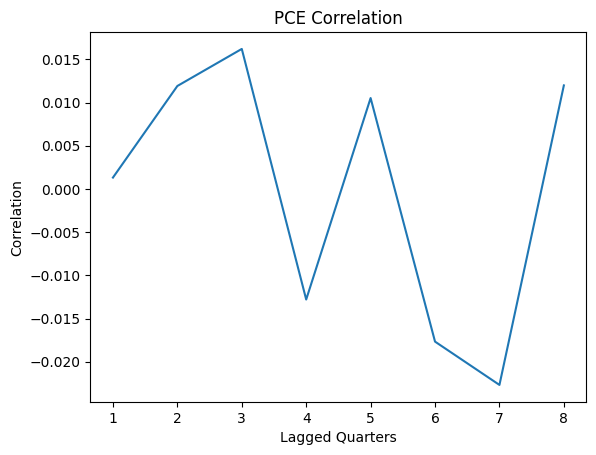

In [45]:
# Calculate the correlation between lagged Federal Funds Rate and PCE
pce_results, pce_best = lag_parameter_search(df_short, "pce_qoq")
max_indicators.loc['PCE'] = pce_best['quarters_lag'], pce_best['corr']

# Visualize correlation by lag
plt.plot(pce_results['quarters_lag'], pce_results['corr'])
plt.title('PCE Correlation')
plt.xlabel('Lagged Quarters')
plt.ylabel('Correlation')
plt.savefig('pce_correlation.png')
plt.show()

Interpreting this plot, the strongest observed correlation between Federal Funds Rate changes and quarterly changes in Personal Consumption Expenditures (PCE) occurs at the 7-quarter lag interval within the 2-year analysis window. However, unlike the CPI analysis, the relationship does not follow a consistent pattern as the lag interval increases. While the lag analysis identifies the interval with the strongest observed correlation, the weakness of the overall relationship indicates that PCE movements are likely influenced by additional economic factors beyond monetary policy changes.

# **Lagged Impact Analysis of FedFund Interest Rates on GDP**


This analysis investigates the timing of the relationship between changes in the Federal Funds Rate and the Quartely percentage growth of GDP.

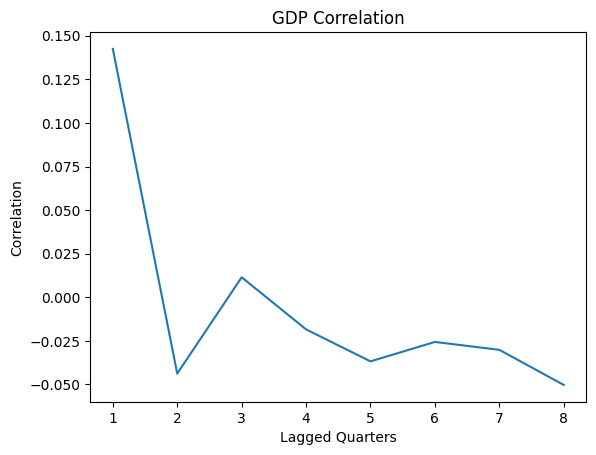

In [46]:
# Calculate the correlation between lagged Federal Funds Rate and GDP
gdp_results, gdp_best = lag_parameter_search(df_short, "gdp_qoq")
max_indicators.loc['GDP'] = gdp_best['quarters_lag'], gdp_best['corr']

# Visualize correlation by lag
plt.plot(gdp_results['quarters_lag'], gdp_results['corr'])
plt.title('GDP Correlation')
plt.xlabel('Lagged Quarters')
plt.ylabel('Correlation')
plt.savefig('gdp_correlation.png')
plt.show()

Interpreting the resulting plot, the strongest observed correlation between Federal Funds Rate changes and quarter-over-quarter changes in Gross Domestic Product (GDP) occurs at the 1-quarter lag within the two-year analysis window. The relationship generally weakens as the lag interval increases, suggesting that the observed association between monetary policy changes and GDP growth does not persist strongly over longer time horizons. However, the correlation remains weak, indicating that Federal Funds Rate adjustments alone explain limited variation in GDP growth. As with the other analyses, these findings identify statistical associations rather than causal effects.

# **Lagged Impact Analysis of FedFund Interest Rates on Unemployment**

This analysis investigates the timing of the relationship between changes in the Federal Funds Rate and the Unemployment Rate as a percentage of the labor force.

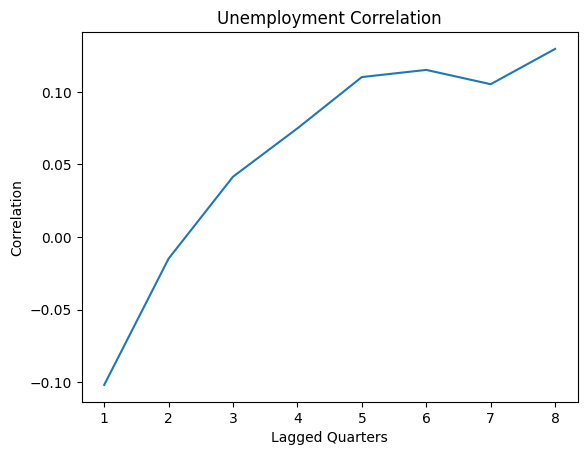

In [47]:
# Calculate the correlation between lagged Federal Funds Rate and Unemployment
unemp_results, unemp_best = lag_parameter_search(df_short, "unemployment_qoq")
max_indicators.loc['Unemployment'] = unemp_best['quarters_lag'], unemp_best['corr']

# Visualize correlation by lag
plt.plot(unemp_results['quarters_lag'], unemp_results['corr'])
plt.title('Unemployment Correlation')
plt.xlabel('Lagged Quarters')
plt.ylabel('Correlation')
plt.savefig('unemployment_correlation.png')
plt.show()

Interpreting the resulting plot, the strongest observed correlation between Federal Funds Rate changes and quarter-over-quarter changes in the Unemployment Rate occurs at the 8-quarter lag within the two-year analysis window. Although the correlation reaches its highest value at the longest tested lag interval, the relationship does not display a strong or consistent pattern across the lag periods analyzed. Since the strongest observed correlation occurs at the maximum tested lag of 8 quarters, expanding the analysis window could provide additional insight into whether a longer-term relationship exists. However, the correlation remains very weak, indicating that Federal Funds Rate changes have limited linear association with changes in the Unemployment Rate within this dataset.

# **Final Conclusions and Future Data Exploration Opportunities**




## **Analysis Objective & Findings**

The focus of this analysis centered upon the lagged relationship between changes in the Federal Funds Rate and four key macroeconomic indicators: **CPI, PCE, Unemployment, and GDP**. By engineering quarterly lag features and comparing correlations across multiple time horizons, the analysis examined how the timing of monetary policy aligns with different aspects of macroeconomic performance. The results indicate that macroeconomic indicators do not respond uniformly to Federal Funds Rate changes, with CPI demonstrating the strongest observed relationship at a short-term lag, while unemployment exhibited its highest observed correlation at a longer lag interval. However, the correlation values all remained weak suggesting that looking strictly at Federal Funds Rate changes provides limited insight into movements in these macroeconomic indicators. These findings highlight the complexity of monetary policy transmission within the broader economy and emphasize that economic outcomes are influenced by multiple factors beyond interest rate adjustments.

In [48]:
# Import dataframe image library to display Table of Max Correlations and Quarter of Observation
import dataframe_image as dfi
dfi.export(max_indicators, 'max_indicators.png',table_conversion='matplotlib')

# Table of Max Correlations and Quarter of Observation
max_indicators


,Quarter,Peak_corr
CPI,1.0,0.25736
PCE,7.0,-0.022687
GDP,1.0,0.142451
Unemployment,8.0,0.129566


##**Implications & Limitations**

The results of this analysis demonstrate the value of lagged feature engineering and descriptive time-series analysis when evaluating macroeconomic data. This is important since delayed relationships may not be evident when comparing interest rates with macroeconomic indicators contemporaneously. However, the content of this analysis is exploratory and should be interpreted with caution. Correlation measures statistical association rather than causation, and many external factors including fiscal policy, global economic conditions, supply chain disruptions, and business cycles can influence macroeconomic outcomes. Additionally, the relatively weak correlation metrics limit the strength of conclusions that can be drawn from this analysis alone.

##**Opportunities for Future Exploration**

Several opportunities exist to extend this analysis and potentially discover deeper insights. Future work could evaluate longer lag intervals to determine whether stronger relationships emerge beyond two years, particularly for indicators where longer lags produced increasing correlations. More advanced statistical techniques, such as multiple linear regression or time-series forecasting models, could provide a more rigorous evaluation of the dynamic relationships between monetary policy and macroeconomic indicators. Additional macroeconomic indicators including housing activity, and consumer confidence metrics could also be incorporated to broaden the scope of analysis of the transmission of monetary policy throughout the economy.